In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import ttest_ind
import scipy.stats as stats

In [3]:
import sqlite3
import pandas as pd

# Creating database connection
conn = sqlite3.connect("inventory.db")

# Fetching vendor summary data
df = pd.read_sql_query(
    "SELECT * FROM vendor_sales_summary",
    conn
)

df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080.0,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038.0,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407.0,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682.0,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109.0,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05
TotalExciseTax,10692.0,1.774226e+03,10975.582240,0.00,4.800000,46.570000,418.650000,3.682428e+05


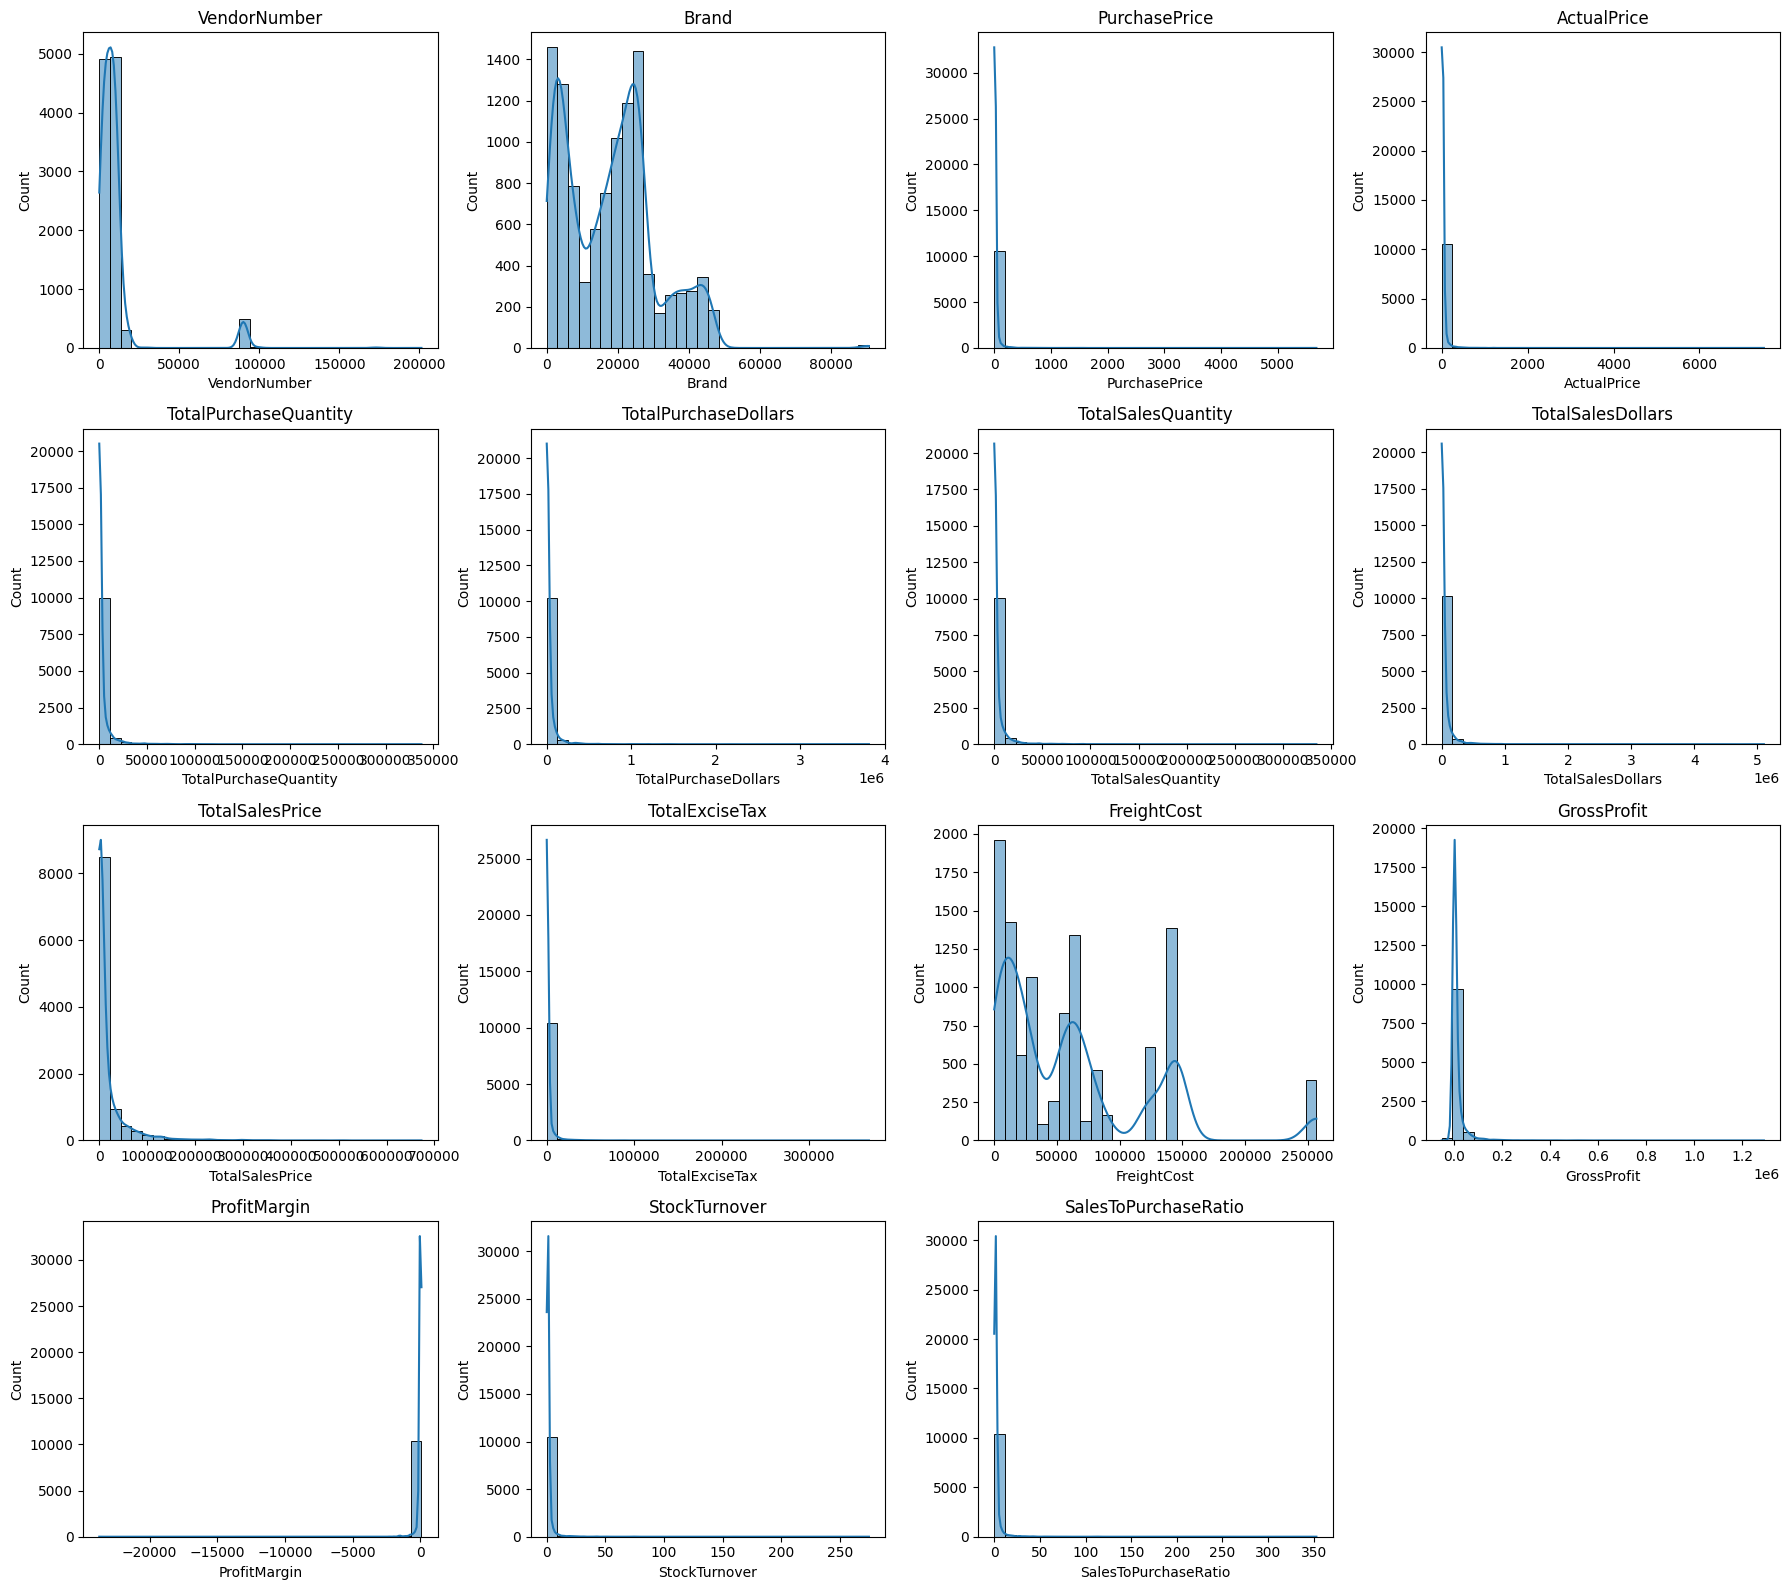

In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns

n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

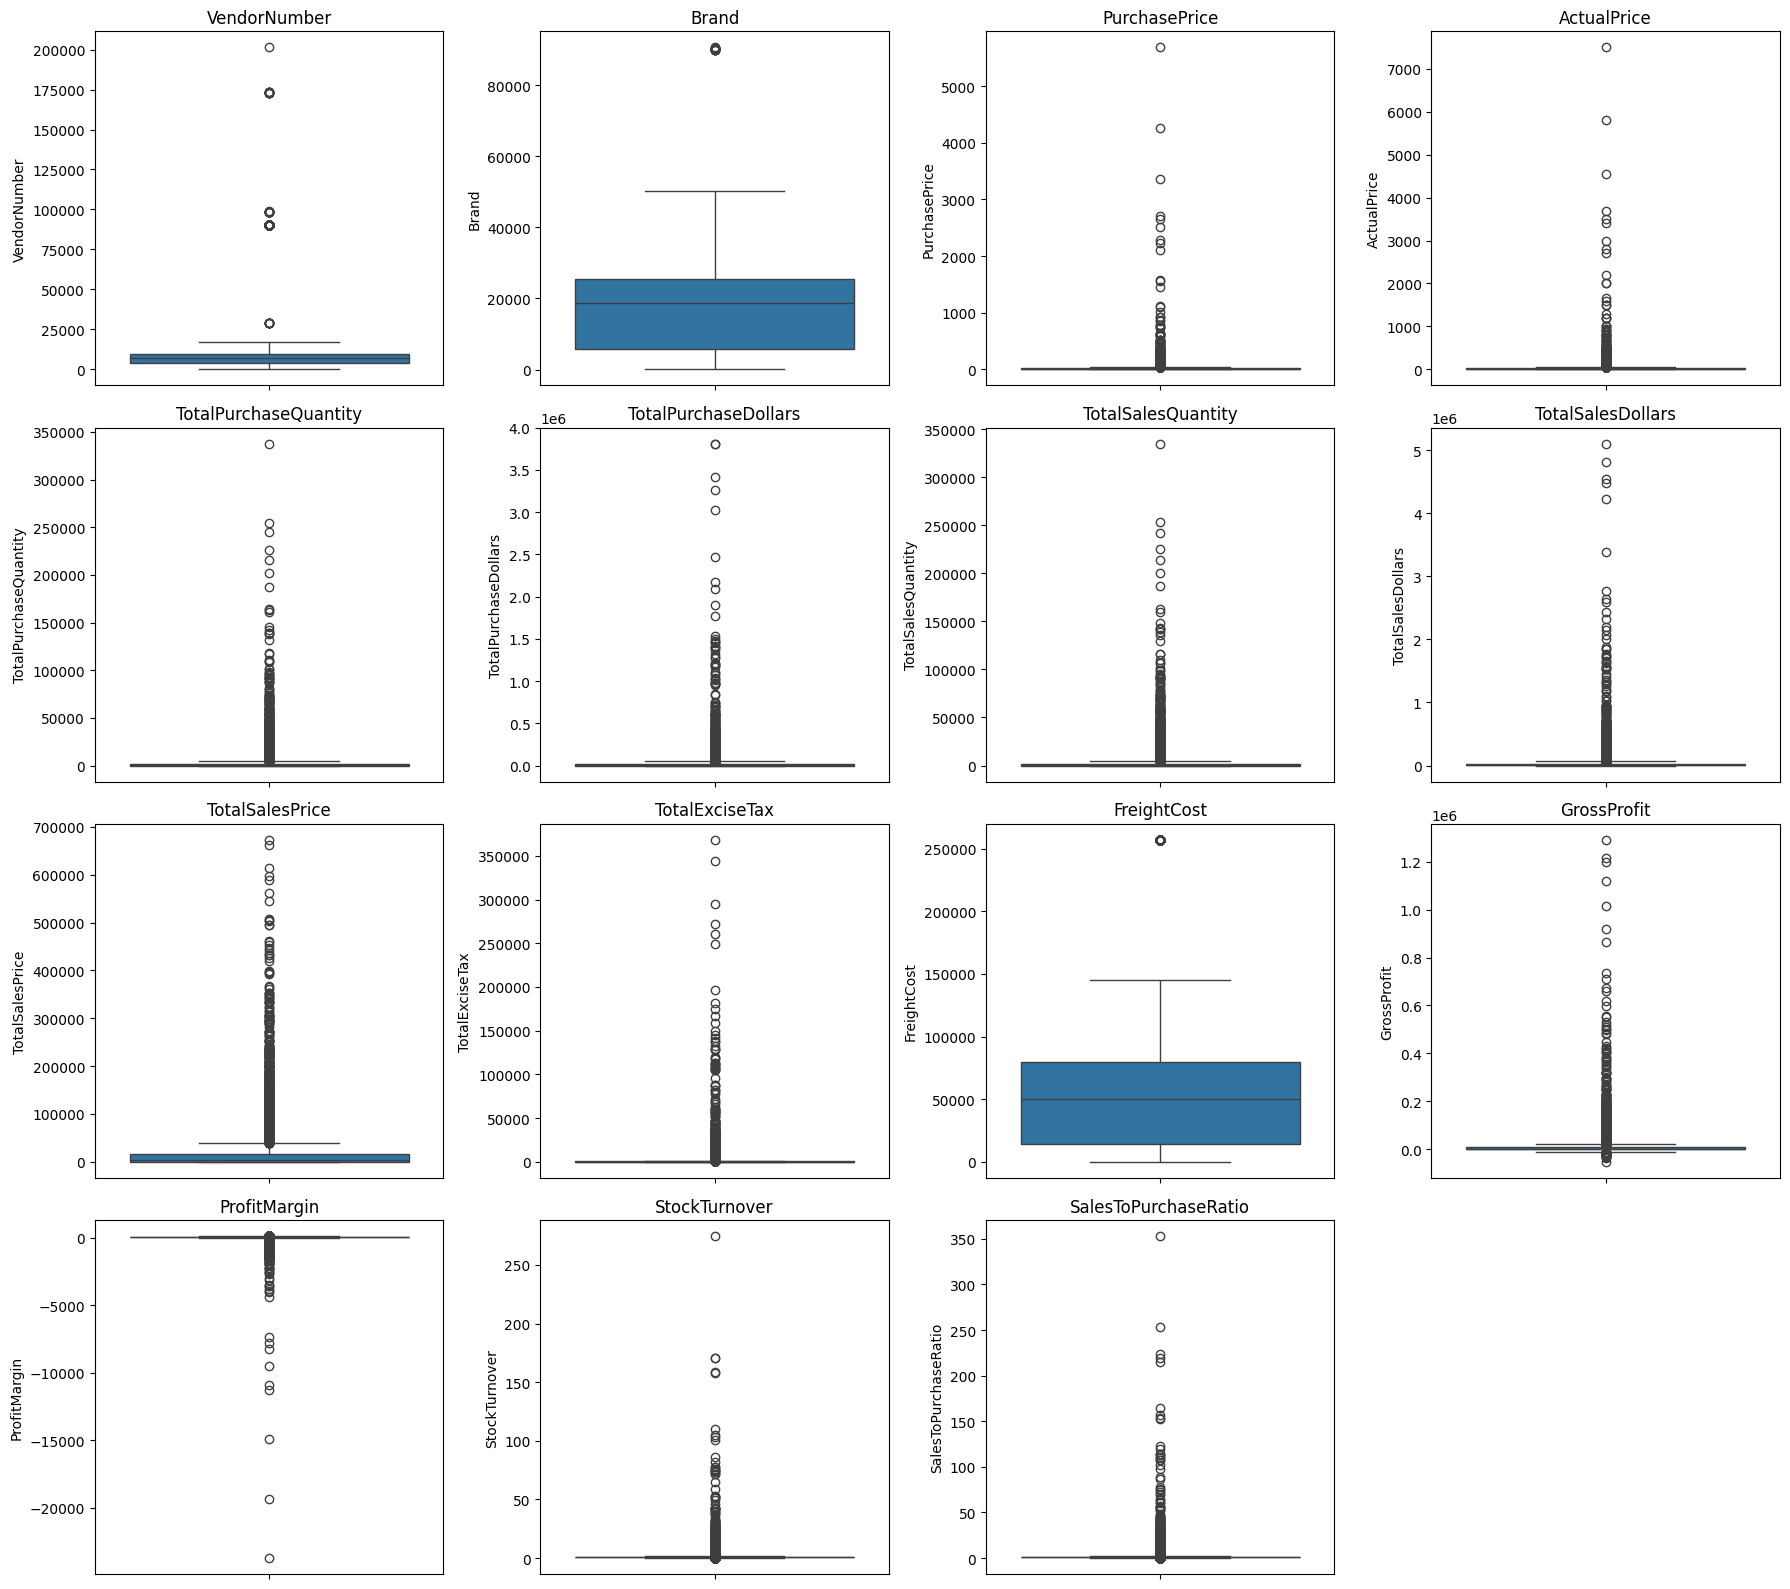

In [6]:
numerical_cols = df.select_dtypes(include=np.number).columns

# Dynamic grid size
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [7]:
pd.read_sql_query("""
PRAGMA table_info(vendor_sales_summary);
""", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,VendorNumber,INTEGER,0,None,0
1,1,VendorName,TEXT,0,None,0
2,2,Brand,INTEGER,0,None,0
3,3,Description,TEXT,0,None,0
4,4,PurchasePrice,REAL,0,None,0
5,5,ActualPrice,REAL,0,None,0
6,6,Volume,TEXT,0,None,0
7,7,TotalPurchaseQuantity,REAL,0,None,0
8,8,TotalPurchaseDollars,REAL,0,None,0
9,9,TotalSalesQuantity,REAL,0,None,0


In [8]:
df = pd.read_sql_query("""
SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
  AND ProfitMargin > 0
  AND TotalSalesQuantity > 0
""", conn)

In [9]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080.0,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038.0,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407.0,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682.0,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109.0,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2.0,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6.0,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2.0,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1.0,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


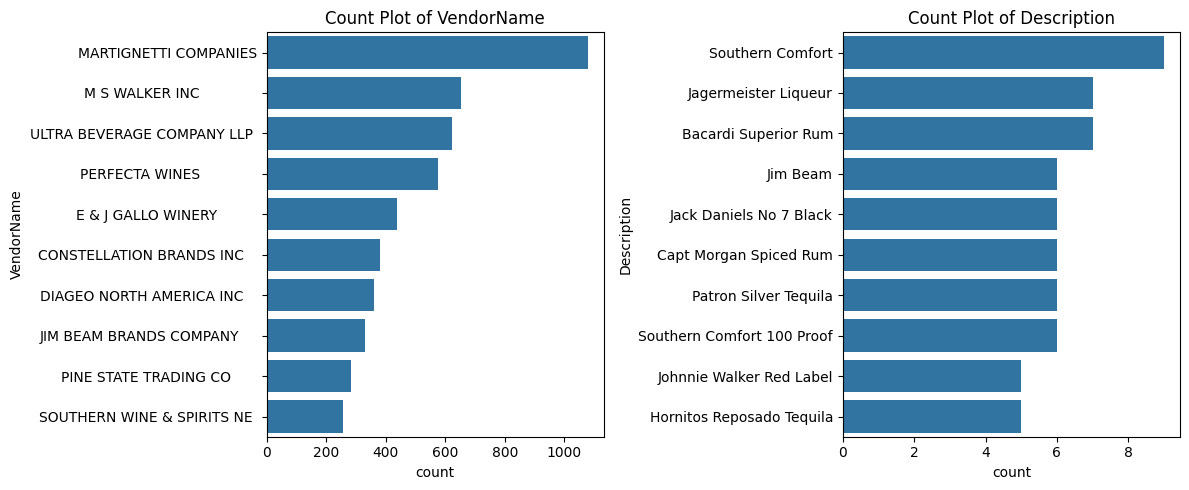

In [10]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index[:10]   # Top 10 categories
    )
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

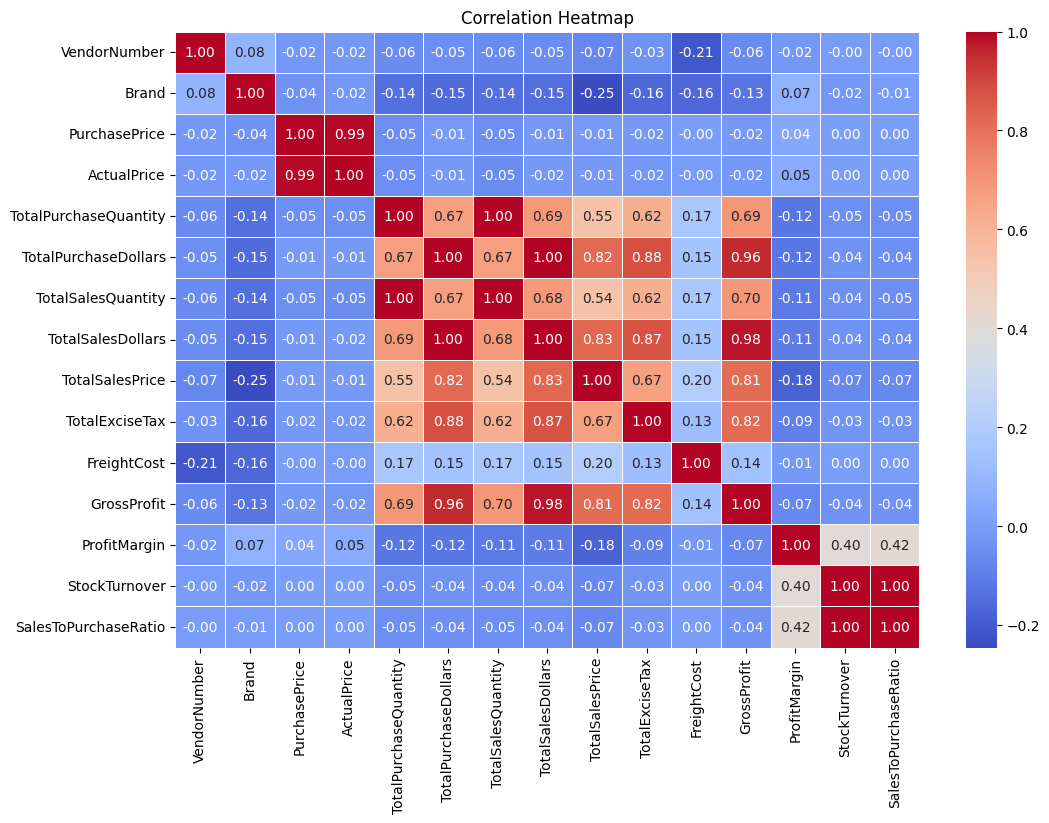

In [11]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [12]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [13]:
low_sales_threshold

np.float64(560.299)

In [14]:
high_margin_threshold

np.float64(64.97017552750113)

In [15]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


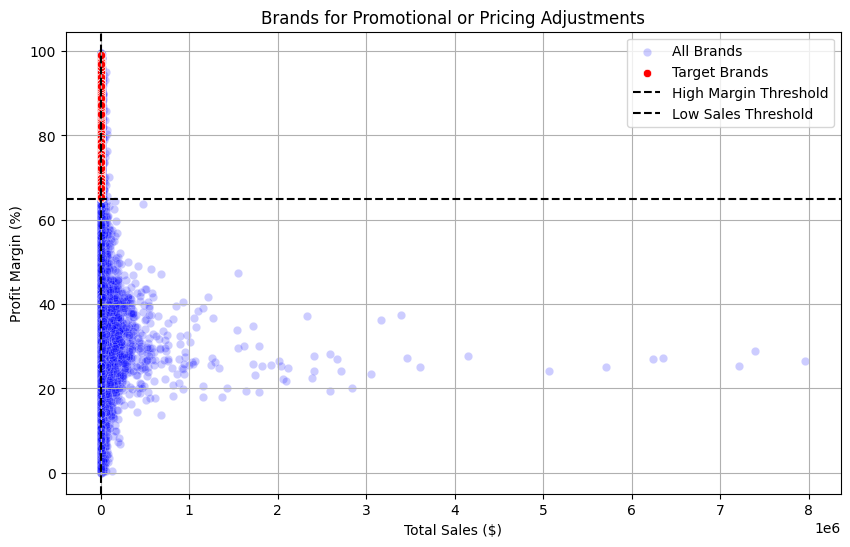

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

plt.axhline(
    high_margin_threshold,
    linestyle='--',
    color='black',
    label='High Margin Threshold'
)

plt.axvline(
    low_sales_threshold,
    linestyle='--',
    color='black',
    label='Low Sales Threshold'
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

Which vendors and brands demonstrate the highest sales performance?

In [17]:
# Top Vendors & Brands by Sales Performance

# Top 10 vendors based on total sales
top_vendors = (
    df.groupby("VendorName")["TotalSalesDollars"]
      .sum()
      .nlargest(10)
)

# Top 10 brands/products based on total sales
top_brands = (
    df.groupby("Description")["TotalSalesDollars"]
      .sum()
      .nlargest(10)
)

# Display the results
print("Top 10 Vendors by Total Sales")
display(top_vendors)

print("Top 10 Brands by Total Sales")
display(top_brands)

Top 10 Vendors by Total Sales


VendorName
DIAGEO NORTH AMERICA INC       67990099.42
MARTIGNETTI COMPANIES          39276398.80
PERNOD RICARD USA              32063196.19
JIM BEAM BRANDS COMPANY        31423020.46
BACARDI USA INC                24854817.14
CONSTELLATION BRANDS INC       24218745.65
E & J GALLO WINERY             18399899.46
BROWN-FORMAN CORP              18247230.65
ULTRA BEVERAGE COMPANY LLP     16502544.31
M S WALKER INC                 14706458.51
Name: TotalSalesDollars, dtype: float64

Top 10 Brands by Total Sales


Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [19]:
def format_dollars(value):
    if value >= 1_000_000_000:
        return f"${value/1_000_000_000:.2f} B"
    elif value >= 1_000_000:
        return f"${value/1_000_000:.2f} M"
    elif value >= 1_000:
        return f"${value/1_000:.2f} K"
    else:
        return f"${value:.2f}"

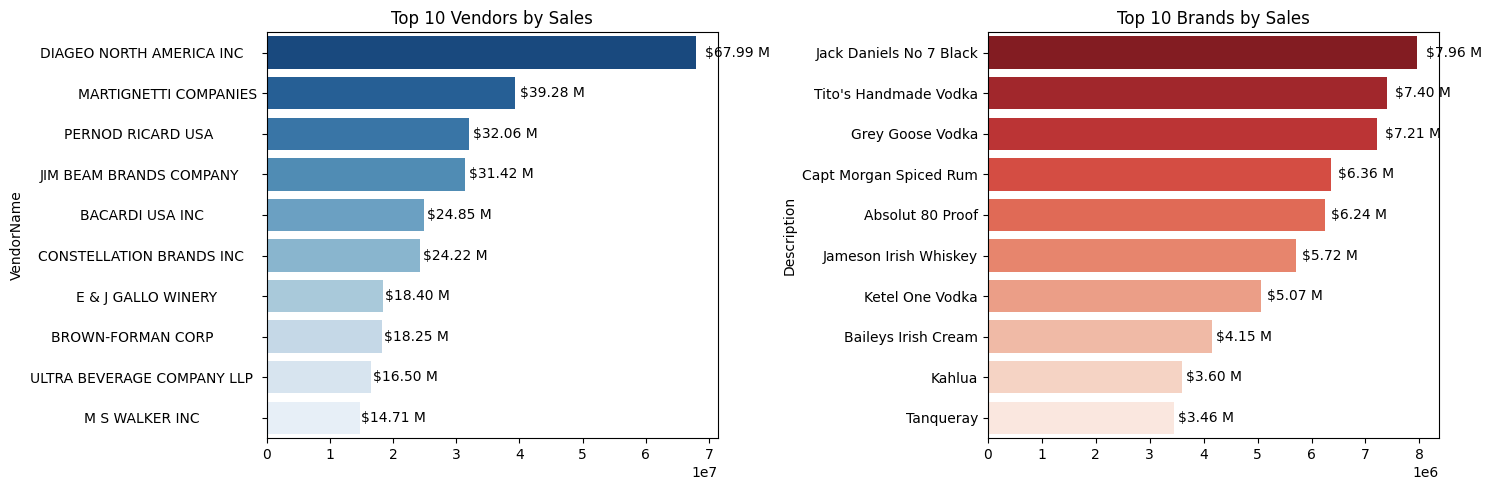

In [20]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)
plt.title("Top 10 Vendors by Sales")

# Add sales labels to each bar
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)
plt.title("Top 10 Brands by Sales")

# Add sales labels to each bar
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.show()

In [21]:
vendor_summary = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()

display(vendor_summary)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
115,WEIN BAUER INC,42694.64,13522.49,56217.13
116,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
117,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
118,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [24]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()

In [25]:
vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars'] /
    vendor_performance['TotalPurchaseDollars'].sum()
) * 100

vendor_performance = vendor_performance.sort_values(
    by='PurchaseContribution%',
    ascending=False
)

display(vendor_performance)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.300345
57,MARTIGNETTI COMPANIES,25464774.04,13811624.76,39276398.80,8.285581
69,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.760554
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.644441
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.671930
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.000042
108,UNCORKED,118.74,58.20,176.94,0.000039
86,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.000025
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.000018


In [26]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = (
    top_vendors['TotalSalesDollars'].apply(format_dollars)
)

top_vendors['TotalPurchaseDollars'] = (
    top_vendors['TotalPurchaseDollars'].apply(format_dollars)
)

top_vendors['GrossProfit'] = (
    top_vendors['GrossProfit'].apply(format_dollars)
)

display(top_vendors)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,$50.10 M,$17.89 M,$67.99 M,16.300345
57,MARTIGNETTI COMPANIES,$25.46 M,$13.81 M,$39.28 M,8.285581
69,PERNOD RICARD USA,$23.85 M,$8.21 M,$32.06 M,7.760554
46,JIM BEAM BRANDS COMPANY,$23.49 M,$7.93 M,$31.42 M,7.644441
6,BACARDI USA INC,$17.43 M,$7.42 M,$24.85 M,5.671930
20,CONSTELLATION BRANDS INC,$15.27 M,$8.95 M,$24.22 M,4.969671
11,BROWN-FORMAN CORP,$13.24 M,$5.01 M,$18.25 M,4.307609
30,E & J GALLO WINERY,$12.07 M,$6.33 M,$18.40 M,3.926791
107,ULTRA BEVERAGE COMPANY LLP,$11.17 M,$5.34 M,$16.50 M,3.633480
53,M S WALKER INC,$9.76 M,$4.94 M,$14.71 M,3.177055


In [27]:
# Calculate cumulative purchase contribution
top_vendors['Cumulative_Contribution%'] = (
    top_vendors['PurchaseContribution%'].cumsum()
)

display(top_vendors)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,$50.10 M,$17.89 M,$67.99 M,16.300345,16.300345
57,MARTIGNETTI COMPANIES,$25.46 M,$13.81 M,$39.28 M,8.285581,24.585926
69,PERNOD RICARD USA,$23.85 M,$8.21 M,$32.06 M,7.760554,32.346479
46,JIM BEAM BRANDS COMPANY,$23.49 M,$7.93 M,$31.42 M,7.644441,39.990920
6,BACARDI USA INC,$17.43 M,$7.42 M,$24.85 M,5.671930,45.662850
20,CONSTELLATION BRANDS INC,$15.27 M,$8.95 M,$24.22 M,4.969671,50.632520
11,BROWN-FORMAN CORP,$13.24 M,$5.01 M,$18.25 M,4.307609,54.940130
30,E & J GALLO WINERY,$12.07 M,$6.33 M,$18.40 M,3.926791,58.866921
107,ULTRA BEVERAGE COMPANY LLP,$11.17 M,$5.34 M,$16.50 M,3.633480,62.500401
53,M S WALKER INC,$9.76 M,$4.94 M,$14.71 M,3.177055,65.677457


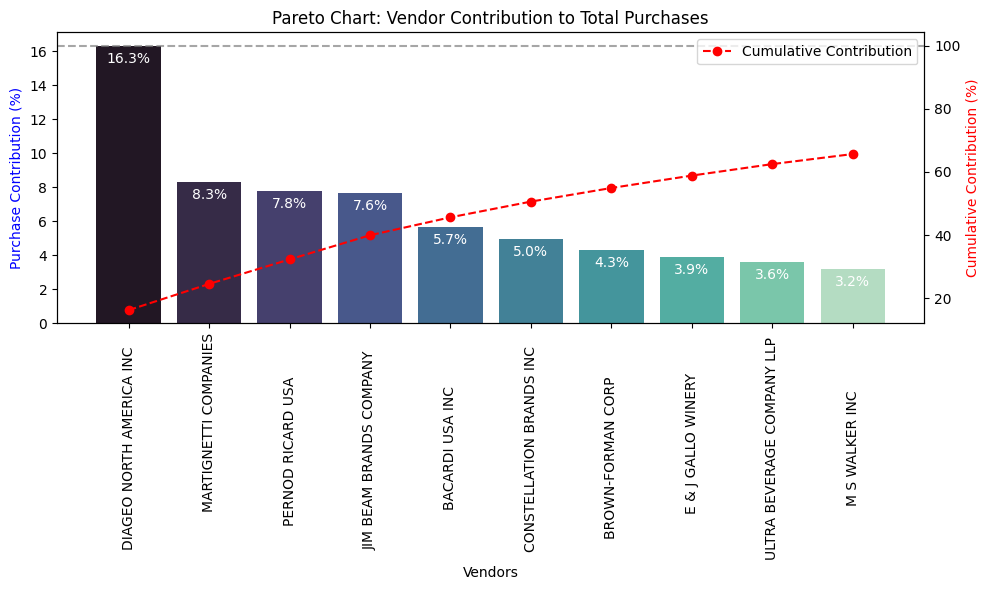

In [28]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar Plot for Purchase Contribution
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette="mako",
    ax=ax1
)

# Add percentage labels on bars
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(
        i,
        value - 1,
        f"{value:.1f}%",
        ha='center',
        fontsize=10,
        color='white'
    )

# Line Plot for Cumulative Contribution
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution'
)

# Formatting
ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel("Purchase Contribution (%)", color='blue')
ax2.set_ylabel("Cumulative Contribution (%)", color='red')
ax1.set_xlabel("Vendors")
ax1.set_title("Pareto Chart: Vendor Contribution to Total Purchases")

# 100% reference line
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [29]:
# Calculate the total purchase contribution of the top 10 vendors
print(
    f"Total Purchase Contribution of top 10 vendors is "
    f"{round(top_vendors['PurchaseContribution%'].sum(), 2)}%"
)

Total Purchase Contribution of top 10 vendors is 65.68%


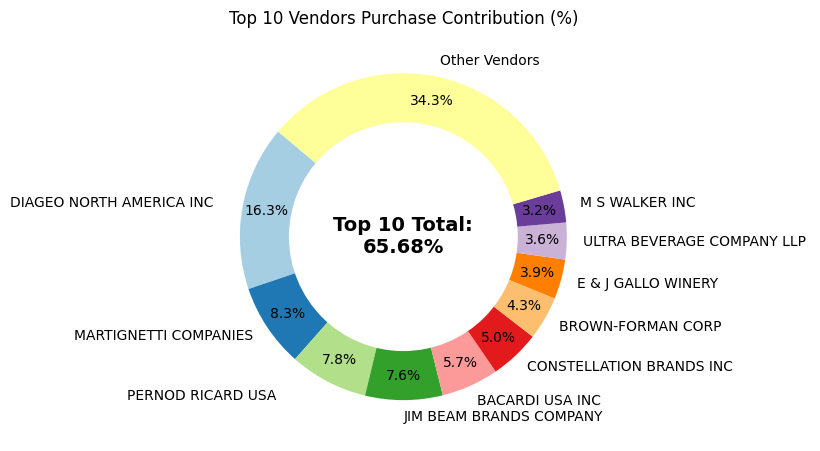

In [30]:
# Prepare data for the donut chart
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

# Calculate the remaining contribution
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Create the donut chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create the donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add total contribution in the center
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendors Purchase Contribution (%)")
plt.tight_layout()
plt.show()

In [31]:
 # Calculate the purchase price per unit
df['UnitPurchasePrice'] = (
    df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']
) 

In [32]:
# Divide purchase quantities into three groups
df['OrderSize'] = pd.qcut(
    df['TotalPurchaseQuantity'],
    q=3,
    labels=['Small', 'Medium', 'Large']
)

In [33]:
df[["OrderSize","TotalPurchaseQuantity"]]

,OrderSize,TotalPurchaseQuantity
0,Large,145080.0
1,Large,164038.0
2,Large,187407.0
3,Large,201682.0
4,Large,138109.0
...,...,...
8559,Small,2.0
8560,Small,6.0
8561,Small,2.0
8562,Small,1.0


In [34]:
# Calculate the average unit purchase price for each order size
order_size_analysis = (
    df.groupby('OrderSize')[['UnitPurchasePrice']]
      .mean()
)

display(order_size_analysis)

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


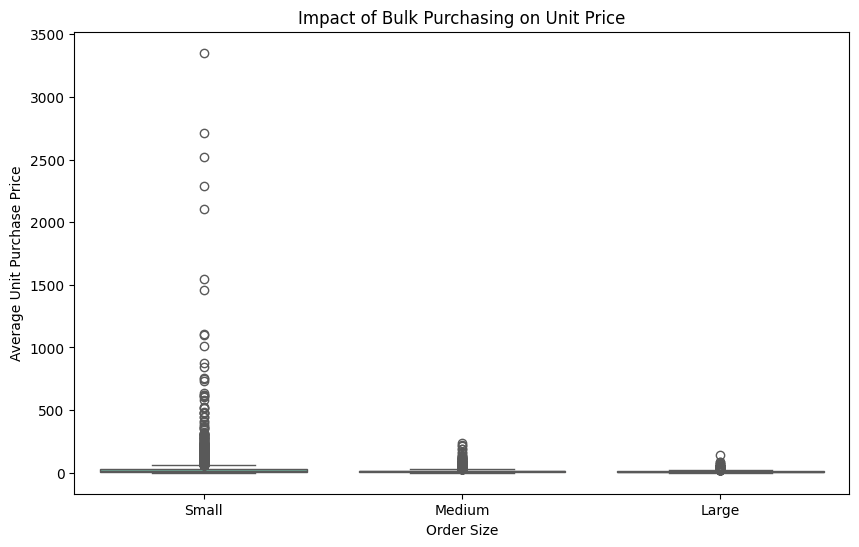

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPurchasePrice",
    palette="Set2"
)

plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")

plt.show()

In [39]:
df[df["StockTurnover"]<1].groupby("VendorName")[["StockTurnover"]].mean().sort_values("StockTurnover",ascending=True).head()

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022


In [40]:
# Calculate the value of unsold inventory
df['UnsoldInventoryValue'] = (
    (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']) *
    df['PurchasePrice']
)

# Display the total unsold inventory value
print(
    "Total Unsold Capital:",
    format_dollars(df['UnsoldInventoryValue'].sum())
)

Total Unsold Capital: $2.71 M


In [41]:
# Aggregate capital locked per vendor
inventory_value_per_vendor = (
    df.groupby("VendorName")["UnsoldInventoryValue"]
      .sum()
      .reset_index()
)

# Sort vendors by highest locked capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue",
    ascending=False
)

# Format the inventory value for better readability
inventory_value_per_vendor["UnsoldInventoryValue"] = (
    inventory_value_per_vendor["UnsoldInventoryValue"]
    .apply(format_dollars)
)

# Display the top 10 vendors
display(inventory_value_per_vendor.head(10))

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,$722.21 K
46,JIM BEAM BRANDS COMPANY,$554.67 K
69,PERNOD RICARD USA,$470.63 K
117,WILLIAM GRANT & SONS INC,$401.96 K
30,E & J GALLO WINERY,$228.28 K
80,SAZERAC CO INC,$198.44 K
11,BROWN-FORMAN CORP,$177.73 K
20,CONSTELLATION BRANDS INC,$133.62 K
62,MOET HENNESSY USA INC,$126.48 K
78,REMY COINTREAU USA INC,$118.60 K


In [42]:
# Find the sales thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Separate profit margins of top and low-performing vendors
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()

low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [43]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

Create a function to calculate the 95% confidence interval for the mean profit margin.

In [44]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))   # Standard Error

    t_critical = stats.t.ppf(
        (1 + confidence) / 2,
        df=len(data) - 1
    )

    margin_of_error = t_critical * std_err

    return (
        mean_val,
        mean_val - margin_of_error,
        mean_val + margin_of_error
    )

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


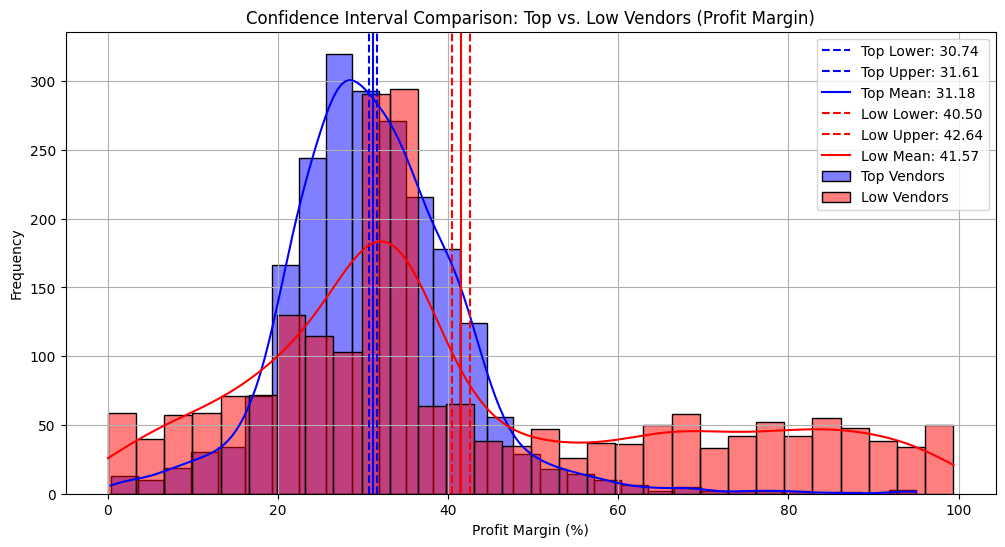

In [45]:
# Calculate confidence intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

# Print confidence intervals
print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

# Create figure
plt.figure(figsize=(12, 6))

# ---------------- Top Vendors ----------------
sns.histplot(
    top_vendors,
    kde=True,
    color="blue",
    bins=30,
    alpha=0.5,
    label="Top Vendors"
)

# Confidence interval lines
plt.axvline(
    top_lower,
    color="blue",
    linestyle="--",
    label=f"Top Lower: {top_lower:.2f}"
)

plt.axvline(
    top_upper,
    color="blue",
    linestyle="--",
    label=f"Top Upper: {top_upper:.2f}"
)

plt.axvline(
    top_mean,
    color="blue",
    linestyle="-",
    label=f"Top Mean: {top_mean:.2f}"
)

# ---------------- Low Vendors ----------------
sns.histplot(
    low_vendors,
    kde=True,
    color="red",
    bins=30,
    alpha=0.5,
    label="Low Vendors"
)

# Confidence interval lines
plt.axvline(
    low_lower,
    color="red",
    linestyle="--",
    label=f"Low Lower: {low_lower:.2f}"
)

plt.axvline(
    low_upper,
    color="red",
    linestyle="--",
    label=f"Low Upper: {low_upper:.2f}"
)

plt.axvline(
    low_mean,
    color="red",
    linestyle="-",
    label=f"Low Mean: {low_mean:.2f}"
)

# Formatting
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypotheses

H₀ (Null Hypothesis):
There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis):
The mean profit margins of top-performing and low-performing vendors are significantly different.

In [46]:
# Calculate sales thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Create two groups
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Welch's Two-Sample T-Test
t_stat, p_value = ttest_ind(
    top_vendors,
    low_vendors,
    equal_var=False
)

# Display the results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top-performing and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top-performing and low-performing vendors.
